In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("synthetic_beach_volley_data.csv", sep=",")

In [3]:
data.head()

,match_id,reception_quality,passing_quality,passing_type,attack_zone,attacker_distance,num_blockers,defense_position,attack_outcome,attack_type
0,2,2,3,Back,right_front,1.4,0,1_open,defended,cut_shot
1,4,5,3,Back,right_back,3.7,0,2_closed,defended,cut_shot
2,9,3,5,Middle,center_front,1.3,1,2_closed,kill,line_shot
3,9,2,1,Wide,right_back,1.4,0,2_closed,kill,poke
4,8,5,4,Close,left_front,1.8,0,2_closed,kill,line_shot


In [4]:
data.columns

Index(['match_id', 'reception_quality', 'passing_quality', 'passing_type',
       'attack_zone', 'attacker_distance', 'num_blockers', 'defense_position',
       'attack_outcome', 'attack_type'],
      dtype='str')

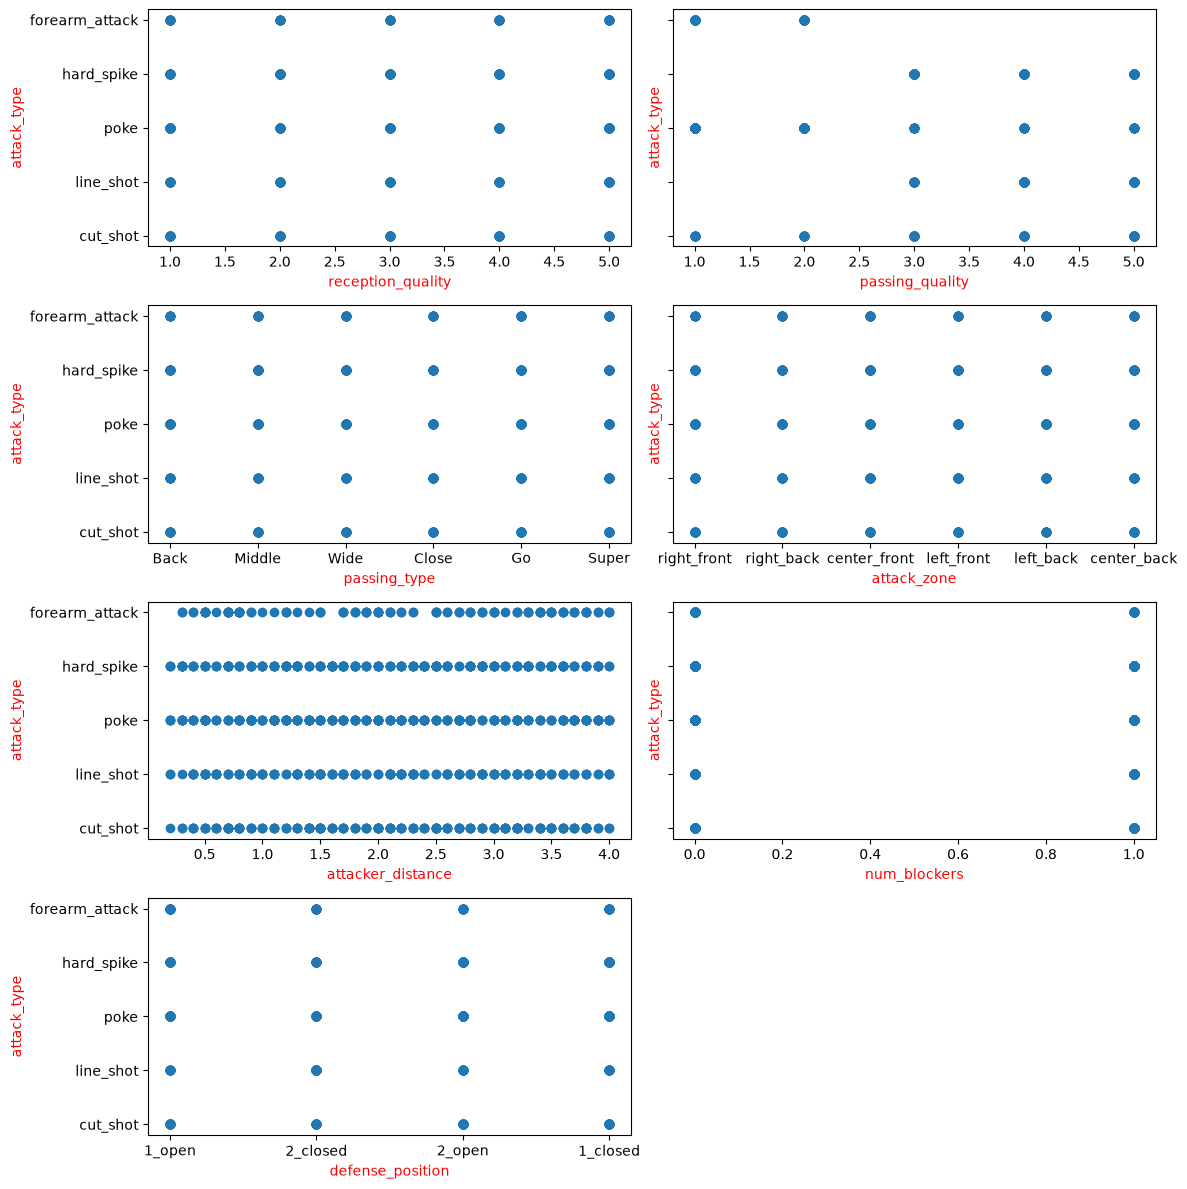

In [5]:
#Exploratory part just to see the graphs
#I removed match_id and attack_outcome because then it's like the model can predict the future which is wrong

feature_names = [col for col in data.columns]
feature_names.remove("match_id")
feature_names.remove("attack_type")
feature_names.remove("attack_outcome")


x_train = np.array(data[feature_names])
y_train = np.array(data["attack_type"])

fig, ax = plt.subplots(4,2, figsize=(12,12), sharey = True)

cnt = 0
for i in range(4):
    for j in range(2):
        if cnt < len(feature_names):
            ax[i,j].scatter(x_train[:,cnt],y_train)
            ax[i,j].set_xlabel(feature_names[cnt], color = "red")
            ax[i,j].set_ylabel("attack_type", color = "red")
        else:
            ax[i,j].axis('off')
        cnt += 1
plt.tight_layout()
plt.show()

In [6]:
#I encoded the columns that contain text in x_train so that the model can read the int values instead of text

X_encoded = pd.get_dummies(data, columns=['passing_type', 'attack_zone', 'defense_position'])


feature_names = [col for col in X_encoded.columns if col not in ['attack_type', 'match_id', 'attack_outcome']]

x_train = np.array(X_encoded[feature_names])
y_train = np.array(data["attack_type"])

In [7]:
print(feature_names)
print(x_train.shape)
print(y_train.shape)

['reception_quality', 'passing_quality', 'attacker_distance', 'num_blockers', 'passing_type_Back', 'passing_type_Close', 'passing_type_Go', 'passing_type_Middle', 'passing_type_Super', 'passing_type_Wide', 'attack_zone_center_back', 'attack_zone_center_front', 'attack_zone_left_back', 'attack_zone_left_front', 'attack_zone_right_back', 'attack_zone_right_front', 'defense_position_1_closed', 'defense_position_1_open', 'defense_position_2_closed', 'defense_position_2_open']
(1000, 20)
(1000,)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train) 

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

LogisticRegression(max_iter=1000)

In [10]:
print(model.coef_)         # αυτά είναι τα "w" — ένα σύνολο βαρών ΑΝΑ κατηγορία (αφού είναι multi-class)

[[-7.32442422e-02  4.00597542e-01  3.41556155e-02  1.69499795e-01
   3.35144059e-02 -5.95632385e-02  1.90135790e-02 -4.49799106e-02
   1.27940910e-01 -6.52380907e-02 -1.19156954e-02 -2.12643563e-02
  -4.40071191e-01  3.57470381e-02  2.88474249e-01  1.59717611e-01
  -1.18102326e-01  8.37124375e-02 -6.88374538e-02  1.13914998e-01]
 [ 5.34235531e-02 -1.48620191e+00  2.77698160e-02 -4.33992073e-01
  -9.36517155e-02  1.07458949e-01  4.25364862e-02 -1.66408411e-02
  -4.37179758e-02  9.80458320e-03  1.10367846e-03  1.67013099e-01
   6.06626046e-02  1.26986613e-02 -4.68752650e-02 -1.88813292e-01
   1.81199132e-01  4.36420834e-01 -3.81000377e-01 -2.30830102e-01]
 [ 5.80485672e-02  7.98784446e-01  1.54878046e-02  1.36666999e-01
   1.62629530e-02 -1.55921352e-01 -6.97920727e-02  3.79113966e-03
   5.29162024e-02  1.73522897e-01 -2.18180209e-02  1.91531593e-01
   3.56606681e-02  3.52581118e-02 -1.76023327e-02 -2.02250252e-01
   1.38533700e-01 -4.05465784e-02 -1.46919289e-01  6.97119351e-02]
 [ 8.13

In [11]:
print(model.intercept_) 

[-0.62183421  3.2120576  -2.25400383 -3.98703387  3.65081431]


In [12]:
print(model.classes_)
print(model.score(x_train, y_train))

['cut_shot' 'forearm_attack' 'hard_spike' 'line_shot' 'poke']
0.48
